## Introduction
This is my personal study guide made while following Andrej Karpathy's makemore series. I'm planning to use the 'brainrot.txt' file as my data to implement basic language models from scratch that can generate brainrot words.

In [1]:
with open('brainrot_corpus.txt','r') as f:
    text = f.read()

In [2]:
words = text.split()
words = [w.lower() for w in words]
words[:10]

['crashout',
 'karen:',
 'bruh,',
 "it's",
 'giving',
 'rizz,',
 'grimace',
 'shake',
 'guy',
 'bro']

In [3]:
len(words)

205085

In [4]:
for w in words[:1]: # only the first word
    chs = ['<S>'] + list(w) + ['<E>'] # start and end character needed since the bigram predicts 1 character at a time
    for ch1,ch2 in  zip(chs,chs[1:]): # print 2 consecutive characters at a time
        print(ch1,ch2) # eg: emma will print em, mm,ma

<S> c
c r
r a
a s
s h
h o
o u
u t
t <E>


## Data Visualization for Bigrams
A tuple of 2 consecutive characters in this use case is called a bigram. First we need to make a dictionary of all bigrams in our dataset and count the number of times they appear, giving us valuable info: given a character c1, what is the most common appearing next character c2 immediately after.

In [5]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0) + 1 # add 1 to bigram count or if bigram not found in b then initialise to 0

In [6]:
# now we need to sort bigrams in order of most common
sorted(b.items(),key = lambda kv : -kv[1]) # b.items turns dictionary into nested tuple, with bigram at 0 and count at 1 and key function
# tells sorted to sort by the second element of the tuple ie the count in descending order (the - sign)

[(('e', '<E>'), 32976),
 (('<S>', 't'), 27023),
 (('t', 'h'), 25786),
 (('h', 'e'), 23517),
 (('<S>', 's'), 18357),
 (('d', '<E>'), 18130),
 (('<S>', 'a'), 17809),
 ((',', '<E>'), 17740),
 (('i', 'n'), 17126),
 (('<S>', 'g'), 17034),
 (('t', '<E>'), 16069),
 (('n', '<E>'), 12945),
 (('<S>', 'c'), 12774),
 (('<S>', 'f'), 11758),
 (('<S>', 'i'), 11707),
 (('s', '<E>'), 11235),
 (('r', 'a'), 11217),
 (('a', 'i'), 11189),
 (('.', '<E>'), 11033),
 (('<S>', 'm'), 10990),
 (('<S>', 'b'), 10712),
 (('a', 't'), 10203),
 (('i', 'd'), 10034),
 (('y', '<E>'), 9645),
 (('e', 'r'), 9606),
 (('r', 'o'), 9261),
 (('o', '<E>'), 9054),
 (('i', 't'), 9030),
 (('r', '<E>'), 9021),
 (('a', '<E>'), 8999),
 (('l', 'e'), 8820),
 (('e', 'd'), 8733),
 (('<S>', 'r'), 8601),
 (('<S>', 'd'), 8484),
 (('r', 'e'), 8473),
 (('<S>', 'w'), 8421),
 (('<S>', 'o'), 8368),
 (('o', 'u'), 7891),
 (('a', 'n'), 7848),
 (('<S>', 'n'), 7124),
 (('r', 'i'), 7015),
 (('a', 'l'), 6434),
 (('e', 'a'), 6433),
 (('a', 'r'), 6279),
 ((

## Basic Pytorch
We need basics of pytorch to train the model using 2D tensors

In [7]:
import torch

In [8]:
a = torch.zeros((3,5),dtype=torch.int)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [9]:
a[1,3] = 1
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

## Lookup Table
For Bigrams, we basically need a big lookup table. Bigrams have character level tokenization, meaning they predict the next character using the last character by seeing a giant lookup table and predicting the character which is most common to come after our latest character in our dataset.

In [10]:
# finding how many characters we have
chars = list(set(''.join(words)))
len(chars)

40

In [11]:
n = len(chars)

In [12]:
# We have 64 unique characters + 2 special chars for start and end tokens so our lookup table should be 66x66
N = torch.zeros((n+2,n+2),dtype=torch.int32)

In [13]:
# now we make encoding - decoding functions to convert a char to int
stoi = {s:i for i,s in enumerate(chars)}
stoi['<S>'] = n
stoi['<E>'] = n+1

In [14]:
itos = {i:s for i,s in enumerate(chars)}
itos[n] = '<S>'
itos[n+1] = '<E>'

In [15]:
# finally filling the lookup table
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

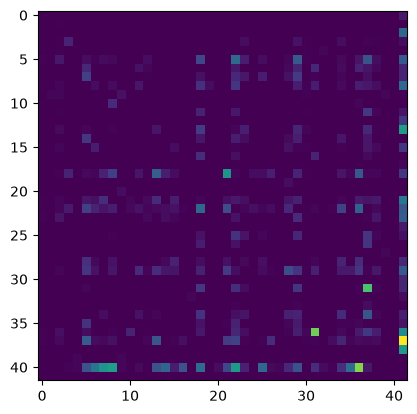

In [16]:
# visualizing this
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)
plt.show()

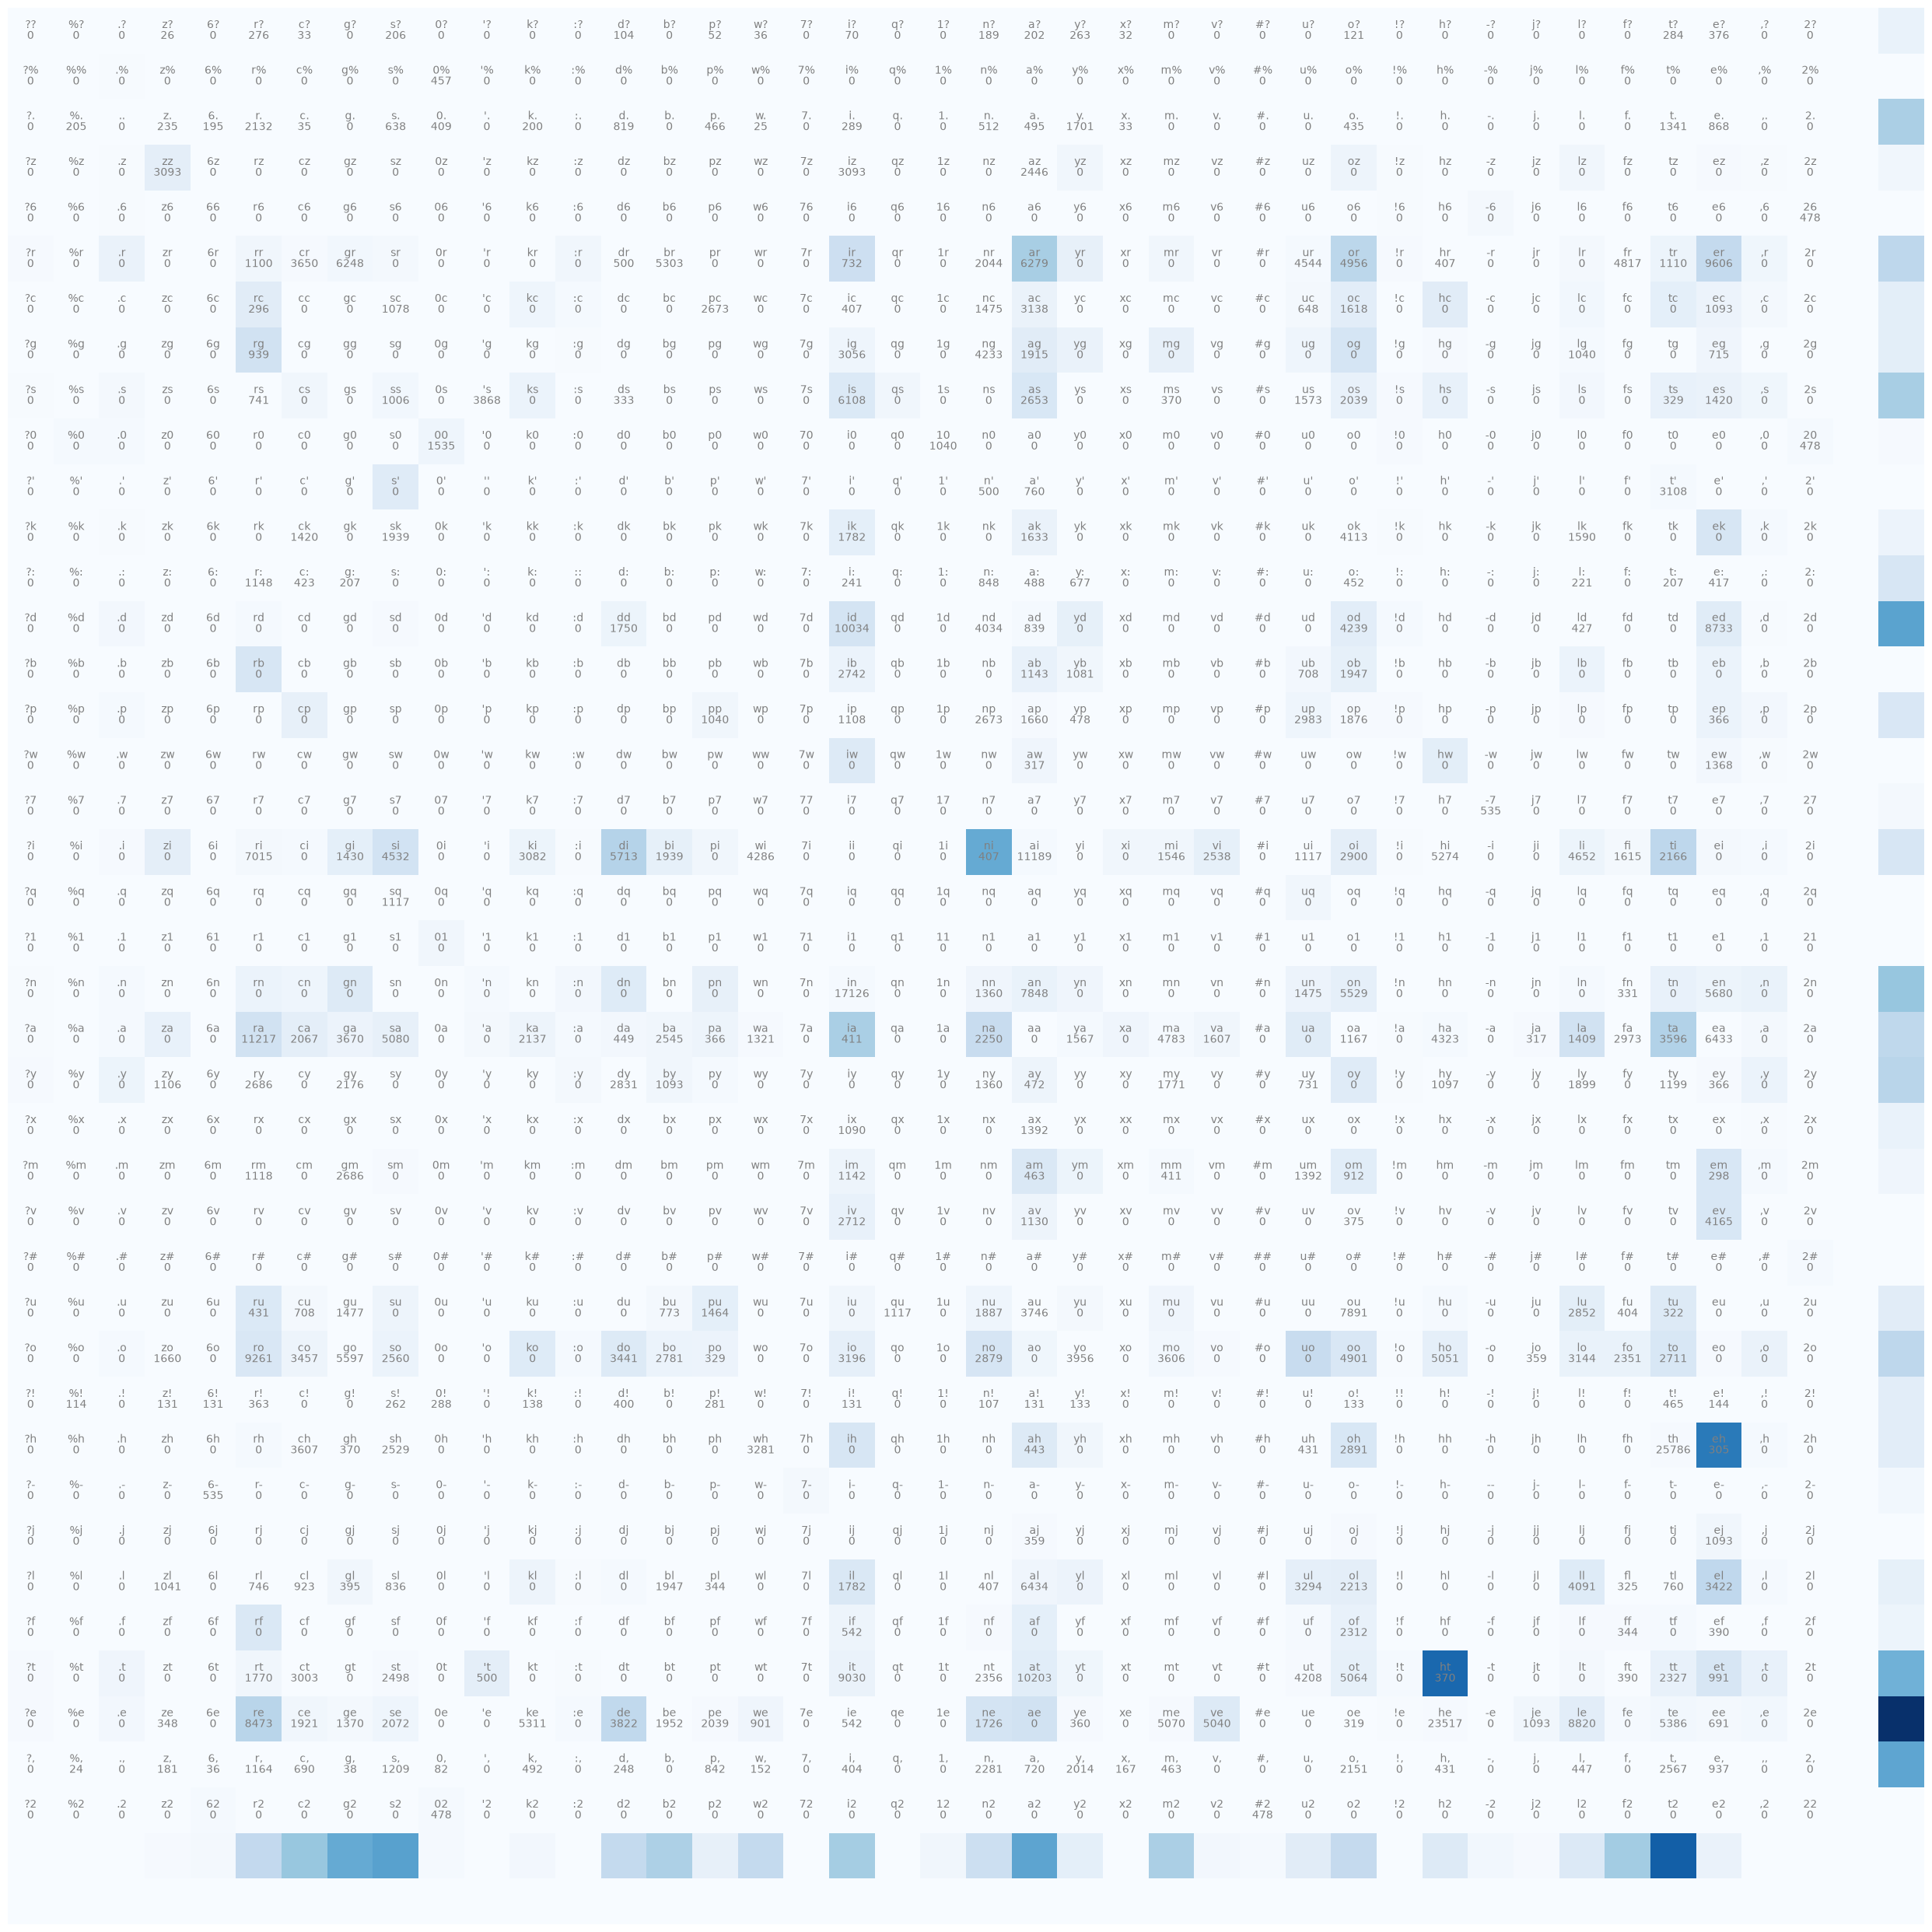

In [17]:
plt.figure(figsize=(32,32))
plt.imshow(N,cmap='Blues')
for i in range(n):
    for j in range(n):
        chstr = itos[i] + itos[j]
        plt.text(i,j,chstr,ha='center',va='bottom',color='gray')
        plt.text(i,j,N[i,j].item(),ha='center',va='top',color='gray')
plt.axis('off')
plt.show()

The above diagram shows us there is some inefficiency. It is not possible for any character to come after ```<E>``` or before ```<S>``` so their respective row/column are all 0. We can reduce this redundancy by only having one special character '.' that signifies end of a word.

In [18]:
# 40 chars because '.' is already a char in the dataset
N = torch.zeros((n,n),dtype=torch.int32)

In [19]:
stio = {s:i for i,s in enumerate(chars)}
itos = {i:s for i,s in enumerate(chars)}

In [20]:
for w in words:
    chs = ['.' ] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1

## Sampling 
Bigrams work by making a probability distribution of all the chars that could come next after a given char and sampling from this probability  distribution.

In [21]:
# first we create an example probability distribution and try to sample from it.
g = torch.Generator().manual_seed(2147483647) # generators are like seed so that given a seed, we always get the same sample
p = torch.rand(3,generator=g) # will distribute a list of 3 random numbers
p

tensor([0.7081, 0.3542, 0.1054])

In [22]:
# now to convert that list into a probability distribution we need that the sum of all elements should be 1
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [23]:
# now using the probability distribution, we will sample. Sampling basically works: the probability of index i being sampled is p[i]
torch.multinomial(p,generator=g,replacement=True, num_samples = 10)
# replacement=True means when an index is sampled, it will not be removed and will be considered again for sampling
# num_samples is the number of samples it generates based on the probability distribution

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0])

In [24]:
# So now we will implement sampling into our N lookup table
# the idea is to sample given the char '.' and keep sampling until '.' appears again
# let's start with sampling 10 words
for i in range(10):
    ix = stoi['.'] # index of '.'
    out = []
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p,generator=g,num_samples=1,replacement=True).item()
        if ix == stoi['.']:
            break
        out.append(itos[ix])
    w = ''.join(out)
    print(w)

inputhite,
barive
s
ge
t
ssep
r
gr
upcofrte
6-7


In [25]:
# the above words were samples using the probability distribution from our data, Bigrams in general are pretty inaccurate
# Here are what the words would look like if instead of learning probability distribution from data, we sample randomly
for i in range(10):
    ix = stoi['.']
    out = []
    while True:
        p = torch.ones(n) / float(n)
        ix = torch.multinomial(p,generator=g,num_samples=1,replacement=True).item()
        if ix == stoi['.']:
            break
        out.append(itos[ix])
    w = ''.join(out)
    print(w)

aor-r#nopz12jid
7o1spd?s:::pvmotu0
azs0plxw?x%7l%-l:ixu7o:wahrk-owrezr0knq%n?giv?#slz0iyai?sxgvdfqt7:tq'6z'''j?wsh%v?,'?oiaqi,,tifr2lkxt'ivcgb1c!rtrgvi'a%vxlw0m7no'%%trdjys?xn2ppk1uzunmz0crin-dwzd#6
1g#-xazby
qn#6o7sz!tdley-h!knpjc!h?7#cindkb''cq?2c1t7vpv,ffhm#nosjtc2kbs6jkpzoiszf'gxhghn?kmoqc,2naw
jlfuw2y!onz?1%u1et1qnlirg'v-ylc'jpcz1ae1rbxvhj-o1b2x?0m%m2uc,wlzisapdpi'cru7u?hyzwzu-:#rpe2n
c6xz,70erxk'uzdlk6!gc!ecyg1%xjwxep
6p00jnvc2a?#q!j1-ffobbhnyb!xw12vpghk7tb1!,y6vbpkvw?mu2bxfl-ql01#zkcgmnan616ch?gk-ejb?rfz1vzxbbbuk2xwfbbastx6j1a2ijf%jtavhlp'olts:,,ge%l!1imcj!bibn'?dc,v#llqps,:z0yzyf:%f'g:kb#alznk7q,1ov?rsj7kwns#2l2ej%
k#f71ix-!-x,k067n#ol1dhhpdaewd:%#st,
zt:zd#


One inefficiency we have so far is that at each iteration we take the sum of a row in N and then calculate probability distribution. This causes a lot of redundancy and we end up calculating the probability distribution for the same row multiple times. Hence, one way to fix that would be to create a matrix P that is filled with the probability distribution itself.

In [26]:
N.shape

torch.Size([40, 40])

In [27]:
# We need a 65x1 tensor containing the sum of all 65 rows.
P = N.float() # copy of N
# P = P / P.sum(1,keepdim=True), same thing as below just creates a new tensor and wastes memory instead of inplace
P /= P.sum(1,keepdim=True)

In [28]:
P.shape

torch.Size([40, 40])

In [29]:
P[0].sum()

tensor(1.)

In the above codeblock, if we had done just `P.sum()` it would have given us a single integer containing sum of all values in the matrix.
`P.sum(0)` gives us a 1x65 tensor containing a row vector which is the sum of all rows, we want a vector which is sum of all columns (hence for each row, we want a value that is the sum of all values in that row) of shape 65x1. `keepdim=True`preserves the original dimensionality by only reducing the dimension across which we sum to 1 ie 65x65 becomes 65x1 instead of a 1D array with 65 elements. 
In `P / P.sum(1,keepdim=True)`, how are we able to divide a 65x65 matrix by a 65x1 ? Division among torch vectors follows **Broadcasting Rules** meaning in both, either a dimension is exactly the same or one of them is 1. Internally, PyTorch creates 65 copies of the 65x1 tensor and joins them making a 65x65 matrix and then divides each element in P with the respective element in this matrix which works for us because in any given row in this new matrix, all elements of that row are the same (sum of that original row) which we divide to the original elements giving us the distribution.

In [30]:
for i in range(10):
    ix = stoi['.']
    out = []
    while True:
        p = P[ix]
        ix = torch.multinomial(p,generator=g,num_samples=1,replacement=True).item()
        if ix==stoi['.']:
            break
        out.append(itos[ix])
    w = ''.join(out)
    print(w)

sachesakid
sathe
nabl
d
bagrouid
greain
10
d
y
th


## Importance of Broadcasting Rules
Broadcasting rules are really important for tensor multiplication and division and if not taken care of, can introduce really subtle hard to catch bugs. Eg: What if we didn't keep `keepdim=True` in the above code.

In [31]:
P2 = N.float()
P2.sum(1).shape

torch.Size([40])

We now have a 1D array of 65 elements (the elements are same just the dimensions have changed).

In [32]:
P2 /= P2.sum(1)
P2[0].sum()

tensor(0.0105)

The above code runs but gives us NaN or sometimes even a number that isn't 1. Why is that ?
Just like when we tried to divide 65x65 by a 65x1 it made copies of 65x1 matrix internally to turn it into a 65x65, similarly when we divide 65x65 by \[65\] it by default turns it into 1x65 row vector and then makes copies of it to form a 65x65, thus the calculation takes place. The only difference being that we want the sum to be columnwise but here because of Broadcasting rules, it performs row wise sum by default even though we have dimension set as 1.

## Loss Function
We need a quantity/ a number to evaluate the quality of predictions of our number. This is the loss of the bigram.

In [33]:
for w in words[0:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2] # probability that ch2 comes after ch1
        print(f'{ch1}{ch2}:{prob:.4f}')

.c:0.0591
cr:0.1448
ra:0.1873
as:0.0342
sh:0.0652
ho:0.1152
ou:0.1134
ut:0.1570
t.:0.2497


We want these probabilities to be as close to 1 as possible (ideally) and so we can measure the loss function as the closeness to 1.
We measure loss for a word but the probabilities are characterwise. So Likelihood of a word = product of probabilities of consecutive characters coming after each other. Hence the more the likelihood, the better but multiplying small probabilities increases precision error so instead we use log likehood = log(a*\b\*c) = log(a) + log(b) + log(c) where a,b,c are consecutive char probabilities. A probability of 1 has log likelihood of 0 and as probability reduces to 0, log approaches $-\inf$. Hence the more the log likelihood the better. But a loss function is the one which is better the less it is. So we use negative loss likelihood, meaning more accuracy = less loss. However absolute log values can get extremely large so to normalize them we can divide it by total number of consecutive character pairs in that word.

In [34]:
for w in words[0:2]:
    negative_log_likelihood = 0
    num_pairs = 0
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        negative_log_likelihood += torch.log(prob)
        num_pairs += 1
    negative_log_likelihood = - negative_log_likelihood
    normalized_nll = negative_log_likelihood / num_pairs
    print(f'{w}:{normalized_nll}')

crashout:2.235305070877075
karen::2.6545374393463135


**GOAL:**
- Maximize likelihood of data w.r.t model parameters (statistical modeling)
- Maximize probability / likelihood of a word
- Maximize log likelihood
- Minimize negative log likelihood
- Minimize normalized negative log likelihood.

## Neural Net Bigram
Till now, we have been relying on a lookup table only. We can make a neural network and train it to output probability distributions accurately given any character.

In [35]:
xs, ys = [],[] # input and output chars to later calculate probability distributions
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [36]:
xs.shape

torch.Size([1110057])

We can't just feed these raw integers to the neural net, we need a better way to capture their relative position in the word and info about the char they represent. A common way to present this is with one hot encoding where a single char becomes a list of 0s and 1s where 1 is at the index $i$ that represents the char.
In the cell below, the shape of `xs_enc` is 1110057x40 indicating 40 columns representing the unique 40 chars and 1110057 chars (because every char appears multiple times in the dataset) from above

In [37]:
import torch.nn.functional as F
xs_enc = F.one_hot(xs, num_classes=n).float()
xs_enc.shape

torch.Size([1110057, 40])

In [38]:
xs_enc

tensor([[0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

Now we need to make a neuron that takes this matrix and calculate activations (immediate outputs of the neuron). A neuron has weights and the operation it basically performs is W\*x. The shape of input x is. (1110057,40), the shape of the weight matrix of a single neuron should be (40,1) because each neuron has 40 weights (not only to carry out matrix multiplication but to represent 40 unique chars) and we have only 1 column vector of these 40 weights because these are weights of only 1 neuron. Had it been a layer of $k$ neurons, the weight matrix would have been (40,$k$).

In [39]:
W = torch.randn((40,1)) # initialize weights randomly
activations = xs_enc @ W # @ is parallel matrix multiplication in pytorch

In [40]:
activations.shape

torch.Size([1110057, 1])

The shape of the activation matrix is (1110057,1) meaning a column vector containing 1110057 values (a value for each char appearance) giving us this neuron's activation value for each char appearance. A low activation value (closer to 0) means the neuron didn't detect any pattern or signal whereas a higher one means some information has been detected. These activations are passed from neuron to neuron, one layer to the next to detect all kinds of signals and info to make the final decision. To make 1 layers of neurons:

In [41]:
W = torch.randn((40,40)) # 40 neurons in a single layer
activations = xs_enc @ W 

In [42]:
activations.shape

torch.Size([1110057, 40])

In [43]:
activations[3,13] # represents the firing rate of the 13th neuron for the 3rd word

tensor(-0.9493)

In [44]:
# The above value will be same as:
print("xs_enc[3]: ",xs_enc[3])
print("W[:,13]: ",W[:,13])
print("Ans: ",(xs_enc[3]*W[:,13]).sum())

xs_enc[3]:  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.])
W[:,13]:  tensor([-1.9341, -0.3147, -1.3605,  0.4524,  0.9834,  0.3374,  0.8553, -2.0412,
        -0.9751, -0.7227, -0.0511, -1.1636, -0.5953, -0.7371, -2.3890,  1.0536,
        -0.0261,  0.9463, -0.3619, -0.0748,  0.8255,  0.3734, -0.9493, -0.8421,
         0.4760, -1.4629, -2.2720,  0.2432, -1.7786, -0.0239, -0.4396,  1.2124,
         1.9344,  1.5725, -1.7885,  0.0718,  2.5196,  0.3735, -1.3776,  1.6066])
Ans:  tensor(-0.9493)


The reason we took 40 neurons in this layers (ie number of neurons = number of chars) because ideally we want the layer's output (activations) to be a probability distribution such that `activations[i]` gives us the list of the 40 probabilities as to how likely is each character to come next after the $i$'th character. Right now, activation values are positive / negative and not between 0,1. Mathematically, we can interpret our current raw acitvations to be logits or log counts. Just like in our lookup table, `N[i]` gave a list of counts of each char coming next after the $i$'th char, current activation are $log(count)$. Hence to get the actual counts, we need to exponentiate them:
$e^{log(count)} = count$. Right now, activations have 1110057 rows, each row represents a character appearance since each character appeared multiple times in our dataset.

In [45]:
logits = activations
counts = logits.exp() # equivalent to N
# Now to get probability distributions we do the same thing as we did with N to ensure every row sums to 1.
probs = counts / counts.sum(1,keepdim=True)

In [46]:
probs.shape

torch.Size([1110057, 40])

In [47]:
print(probs[0].shape) # gives probability distribution of chars to come next after char represented by 0
probs[0]

torch.Size([40])


tensor([0.0194, 0.0086, 0.0042, 0.0265, 0.0171, 0.0391, 0.0096, 0.0945, 0.0086,
        0.0109, 0.0591, 0.0149, 0.0068, 0.0042, 0.0213, 0.0530, 0.0251, 0.0144,
        0.0098, 0.0022, 0.0130, 0.0117, 0.0053, 0.0776, 0.0026, 0.0159, 0.0053,
        0.0885, 0.0152, 0.0050, 0.0014, 0.0943, 0.0223, 0.1118, 0.0060, 0.0008,
        0.0293, 0.0111, 0.0044, 0.0291])

Congratulations, you just made the **Softmax** function that turns raw logits to probability distributions: \
$\frac{e^{z_i}}{\sum^K_{j=1}{e^{z_j}}}$

In [50]:
nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item()
    y = ys[i].item()
    print("Input character ", itos[x]," is represented by ",x)
    print("Its actual output is ",itos[y]," and is represented by ",y)
    print("Probability that ",itos[y]," follows ",itos[x]," according to activations is ",probs[x,y].item())
    ll = torch.log(probs[x,y])
    print("Log likelihood ",ll.item())
    nll = -ll
    print("Negative Log likelihood ", nll.item())
    nlls[i] = nll
print("Average negative log likelihood ",nlls.mean().item())

Input character  .  is represented by  2
Its actual output is  c  and is represented by  6
Probability that  c  follows  .  according to activations is  0.04578009992837906
Log likelihood  -3.0839056968688965
Negative Log likelihood  3.0839056968688965
Input character  c  is represented by  6
Its actual output is  r  and is represented by  5
Probability that  r  follows  c  according to activations is  0.014499391429126263
Log likelihood  -4.233648777008057
Negative Log likelihood  4.233648777008057
Input character  r  is represented by  5
Its actual output is  a  and is represented by  22
Probability that  a  follows  r  according to activations is  0.017752796411514282
Log likelihood  -4.031212329864502
Negative Log likelihood  4.031212329864502
Input character  a  is represented by  22
Its actual output is  s  and is represented by  8
Probability that  s  follows  a  according to activations is  0.0085647813975811
Log likelihood  -4.760096549987793
Negative Log likelihood  4.7600965

An average negative log likelihood of 3.8 is horrible because all our weights were assigned randomly. So now, we need to apply backpropagation, calculate gradients and improve the weights.

In [54]:
W = torch.randn((n,n),requires_grad = True)
for i in range(100):
    # forward pass
    logits = xs_enc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1,keepdim=True)
    loss = -probs[xs,ys].log().mean()
    # backward pass
    W.grad = None
    loss.backward()
    # update
    W.data += -50*W.grad # lr = 50
print(loss.item())

2.574613332748413


What is considered a good loss ? When we were using a bigram lookup table, our loss was around 2.6 which is what we expect our neural network to come to and as we can see above, our loss is almost 2.6. The reason we use neural nets is because they are much more scalable. For complex language modelling if we decide to predict next chars using the last 2 or 3 or more chars, we can't keep such a huge lookup table but the neural network remains similar and easier in complexity. Let's predict some words using the neural net.

In [56]:
logits = xs_enc @ W
counts = logits.exp()
probs = counts / counts.sum(1,keepdim=True)
for i in range(5):
    ix = stoi['.']
    out = []
    while True:
        p = probs[ix]
        ix = torch.multinomial(p,generator=g,num_samples=1,replacement=True).item()
        if ix==stoi['.']:
            break
        out.append(itos[ix])
    w = ''.join(out)
    print(w)

gois
g7wraonrorallt
tror
o
grabo


## Smoothing/ Regularization
Models can overfit or become overconfidence sometimes when they assign sharp probabilities, i.e 1 char gets overwhelming probability in the distribution. So we need a way to smooth or make the distribution more uniform while also keeping the training mechanism of assigning likely chars higher probs. So we introduce a regularization term to loss. To make all probabilities the same, we would want all the counts to be same, hence all the logits to be the same. But we can only influence the weights not the inputs so the only way to make sure that all logits are equal is to make all logits 0 by making W 0. Hence the closer W approaches to 0, the more uniform our probability gets. Hence we need to add this term to loss to penalize (increase loss) if W is farther away from 0. Hence we add this **regularization term** to the loss:
$(W\*\*2).mean()$ to the loss. $W\*\*$ because we don't care about positive or negative, but absolute value to check if W is closer to 0, we use mean because squaring W gives us a matrix and we need a single number to add to the loss so we take the average. Finally we multiply this term with a float before adding it to the loss because these values can be large and hence undermine the actual negative log likelihood which we need to prioritize to get accurate probs.

In [57]:
W = torch.randn((n,n),requires_grad=True)
for i in range(100):
    # forward pass
    logits = xs_enc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1,keepdim=True)
    loss = -probs[xs,ys].log().mean() + 0.01*(W**2).mean() # added regularization
    # backward pass
    W.grad = None
    loss.backward()
    # update
    W.data -= 50*W.grad
print(loss)

tensor(2.5947, grad_fn=<AddBackward0>)


## Exercises:
**E01**: train a trigram language model, i.e. take two characters as an input to predict the 3rd one. Feel free to use either counting or a neural net. Evaluate the loss; Did it improve over a bigram model? \
E02: split up the dataset randomly into 80% train set, 10% dev set, 10% test set. Train the bigram and trigram models only on the training set. Evaluate them on dev and test splits. What can you see?
E03: use the dev set to tune the strength of smoothing (or regularization) for the trigram model - i.e. try many possibilities and see which one works best based on the dev set loss. What patterns can you see in the train and dev set loss as you tune this strength? Take the best setting of the smoothing and evaluate on the test set once and at the end. How good of a loss do you achieve?
E04: we saw that our 1-hot vectors merely select a row of W, so producing these vectors explicitly feels wasteful. Can you delete our use of F.one_hot in favor of simply indexing into rows of W?
E05: look up and use F.cross_entropy instead. You should achieve the same result. Can you think of why we'd prefer to use F.cross_entropy instead?